In [7]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt

In [3]:
df1 = pd.read_csv("Practicas/IDEPAR138.csv")

In [ ]:
# Obteniendo la primera columna entera de datos.
LaPrimera = df1.columns[0] # --> De el File DF1 Se define el nombre de la columna [0]

# Buscando el contenido de la columna por su nombre.
DatosFromLaPrimera = df1[LaPrimera] # --> El nombre va sin comillas.
print(DatosFromLaPrimera)


0         1748055898
1         1748056188
2         1748056485
3         1748056798
4         1748057098
             ...    
122446    1788446685
122447    1788446989
122448    1788447293
122449    1788447581
122450    1788447885
Name: epoch, Length: 122451, dtype: int64


In [ ]:
# Convertimos los datos un datetime
df1[LaPrimera] = pd.to_datetime(df1[LaPrimera], unit="s")

# Procedemos a ver solo las primeras 3 filas con el .head()
print(df1[LaPrimera].head()) # Si al argumento le pones un numero te muestra un numero.

0   2025-05-24 03:04:58
1   2025-05-24 03:09:48
2   2025-05-24 03:14:45
3   2025-05-24 03:19:58
4   2025-05-24 03:24:58
Name: epoch, dtype: datetime64[s]


### 🗓️ Extracción de Fechas con `.dt` en Pandas

Una vez convertida la columna con `pd.to_datetime(df[LaPrimera], unit='s')`, podemos extraer componentes individuales mediante el accesor `.dt`:

| Componente | Método / Atributo | Ejemplo de Uso | Resultado |
| :--- | :--- | :--- | :--- |
| **Fecha sola** | `.dt.date` | `df[LaPrimera].dt.date` | `2025-05-25` |
| **Hora del día** | `.dt.hour` | `df[LaPrimera].dt.hour` | `14` *(0 a 23)* |
| **Día de semana** | `.dt.day_name()` | `df[LaPrimera].dt.day_name()` | `Sunday` |
| **Año** | `.dt.year` | `df[LaPrimera].dt.year` | `2025` |
| **Mes** | `.dt.month` | `df[LaPrimera].dt.month` | `5` *(1 a 12)* |

> 💡 **Tip:** Puedes asignar estas extracciones directamente a **nuevas columnas**:
> ```python
> df['Hora'] = df[LaPrimera].dt.hour
> df['Dia'] = df[LaPrimera].dt.day_name()
> ```

In [12]:
# Asignaremos una nueva columna al DataFrame
df1["Dia"] = df1[LaPrimera].dt.day_name()

# Printeamos para comprobar
for i in df1:
    print(i)

epoch
solarRadiationHigh
winddirAvg
humidityAvg
metric.tempAvg
metric.windspeedAvg
metric.windgustHigh
metric.dewptAvg
metric.pressureMin
metric.precipTotal
Dia


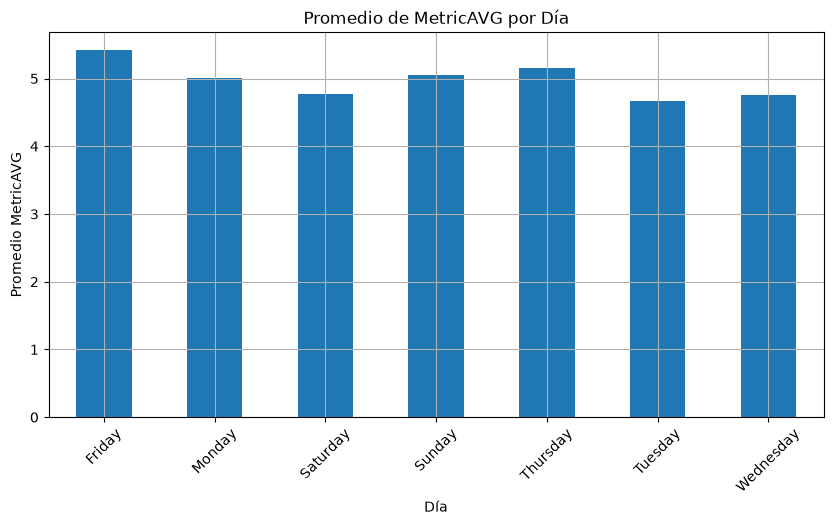

In [15]:
# AHora lo vamos graficar segun el dia.
df1.groupby('Dia')['metric.tempAvg'].mean().plot(
    kind='bar', # Usa 'line' si es una secuencia continua de fechas, o 'bar' si son días de la semana
    figsize=(10, 5),
    grid=True
)

# Etiquetas
plt.title('Promedio de MetricAVG por Día')
plt.xlabel('Día')
plt.ylabel('Promedio MetricAVG')
plt.xticks(rotation=45) # Rota los nombres en el eje X para leer mejor
plt.show()